In [1]:
import sys, os
sys.path.append("/cluster/home/vogtva/pde-data-gen")
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

In [2]:
import xarray as xr
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from matplotlib.animation import FuncAnimation

In [3]:
ds = xr.open_dataset('../output_merged.nc')

In [4]:
df = pd.read_csv('/cluster/scratch/vogtva/data/bruss/int/_dataset.csv')

In [5]:
data = ds["data"]

In [6]:
dt = np.diff(ds["data"], axis=1)

<Axes: >

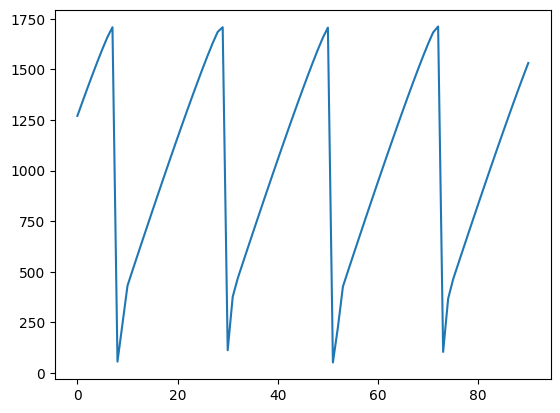

In [14]:
i = 22
u = data[i, :, 1]
u_t = dt[i, :, 1]
n =  np.linalg.norm(u, axis=(1,2))
n_t = np.linalg.norm(u_t, axis=(1,2))
# sns.lineplot(n[10:])
sns.lineplot(n[10:])

In [8]:
df.iloc[0]

A                                                               0.5
B                                                          3.166667
Du                                                              1.0
Dv                                                              8.0
n_snapshots                                                     101
idx                                                               0
mean_deviation                                           339.001709
std_deviation                                            199.365738
max_dx                                                          0.0
mean_dx                                                         0.0
max_dt                                                   711.357056
mean_dt                                                  136.493729
dominant_power                                              0.29095
total_power                                                9.273995
max_u             <xarray.Variable ()> Size: 4B\

In [9]:
ds["data"][0, 0, 0].var()

<xarray.DataArray 'data' ()> Size: 4B
array(0.00978529, dtype=float32)
Coordinates:
    component   <U1 4B 'u'
    snapshot    int64 8B 0
    trajectory  int64 8B 0

In [15]:
d = data[22,10:,1]
d.shape

(91, 128, 128)

MovieWriter ffmpeg unavailable; using Pillow instead.


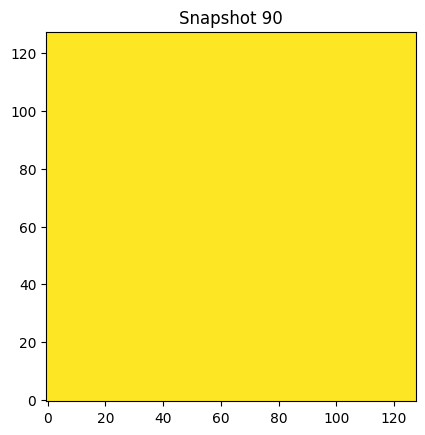

In [16]:
fig, ax = plt.subplots()
im = ax.imshow(d[0], cmap='viridis', origin='lower', animated=True)
ax.set_title('Snapshot 0')

def update(frame):
    im.set_array(d[frame])
    ax.set_title(f'Snapshot {frame}')
    return im,

ani = FuncAnimation(fig, update, frames=d.shape[0], interval=50, blit=True)

ani.save('v.gif')